In [2]:
import numpy as np
import pandas as pd

In [5]:
production_areas_data = pd.read_csv("../Data/raw/Breakdown_of_main_electricity_generation_facilities_in_France,_excluding_solar_and_wind_power_plants_2026-02-25_09-08.csv", sep=";")
generation_data = pd.read_csv("../Data/raw/Evolution_of_power_generation_in_France_2026-03-02_18-36.csv", delimiter=";")
countries = pd.read_csv("../Data/raw/ALLCOUNTRIES.csv")

/var/folders/nc/h_k99bk14lv76j0fpvszb2f40000gn/T/ipykernel_12055/2720154145.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  countries = pd.read_csv("../Data/raw/ALLCOUNTRIES.csv")


In [35]:
generation_data

,Date,Filière,Valeur (TWh),Nature
0,1995-01,Nuclear,"36,909",Données Consolidées
1,1995-02,Nuclear,"30,157",Données Consolidées
2,1995-03,Nuclear,"32,737",Données Consolidées
3,1995-04,Nuclear,"29,125",Données Consolidées
4,1995-05,Nuclear,"26,749",Données Consolidées
...,...,...,...,...
2759,2025-10,Total generation,"44,650769402949",Données Consolidées
2760,2025-11,Total generation,"49,905099386246",Données Consolidées
2761,2025-12,Total generation,"56,384121200713",Données Consolidées
2762,2026-01,Total generation,"57,467545370334",Données Consolidées


In [36]:
production_areas_data

,Commune,Longitude,Latitude,Filière,Valeur (MW)
0,Saint-Vulbas,5.270397,45.822404,Nuclear,3580
1,Cruas,4.756096,44.656491,Nuclear,3660
2,Chooz,4.801001,50.089525,Nuclear,3000
3,Nogent-sur-Seine,3.499683,48.496487,Nuclear,2620
4,Belleville-sur-Loire,2.845587,47.501500,Nuclear,2620
...,...,...,...,...,...
139,Vitry-sur-Seine,2.394516,48.788118,Fossil-fired thermal,350
140,Gardanne,5.480112,43.452894,Renewable thermal and waste,150
141,Étagnac,0.783565,45.890606,Renewable thermal and waste,"55,25"
142,Biganos,-0.949164,44.660950,Renewable thermal and waste,"59,5"


In [11]:
countries = countries.iloc[7:]
countries.columns = countries.iloc[0]
countries = countries.iloc[1:]
countries

7,Country,Time,Balance,Product,Value,Unit
8,Australia,November 2025,Net Electricity Production,Electricity,21355.0142,GWh
9,Australia,November 2025,Net Electricity Production,Hydro,965.5352,GWh
10,Australia,November 2025,Net Electricity Production,Total Combustible Fuels,11343.0954,GWh
11,Australia,November 2025,Net Electricity Production,"Coal, Peat and Manufactured Gases",8266.798,GWh
12,Australia,November 2025,Net Electricity Production,Oil and Petroleum Products,263.3526,GWh
...,...,...,...,...,...,...
157377,IEA Total,January 2010,Total Exports,Electricity,32372.583,GWh
157378,IEA Total,January 2010,Used for pumped storage,Electricity,6869.253,GWh
157379,IEA Total,January 2010,Distribution Losses,Electricity,62000.733,GWh
157380,IEA Total,January 2010,Final Consumption (Calculated),Electricity,877213.615,GWh


In [41]:
countries.columns

Index(['Country', 'Time', 'Balance', 'Product', 'Value', 'Unit'], dtype='object', name=7)

In [42]:
countries["Time"].unique()

array(['November 2025', 'October 2025', 'September 2025', 'August 2025',
       'July 2025', 'June 2025', 'May 2025', 'April 2025', 'March 2025',
       'February 2025', 'January 2025', 'December 2024', 'November 2024',
       'October 2024', 'September 2024', 'August 2024', 'July 2024',
       'June 2024', 'May 2024', 'April 2024', 'March 2024',
       'February 2024', 'January 2024', 'December 2023', 'November 2023',
       'October 2023', 'September 2023', 'August 2023', 'July 2023',
       'June 2023', 'May 2023', 'April 2023', 'March 2023',
       'February 2023', 'January 2023', 'December 2022', 'November 2022',
       'October 2022', 'September 2022', 'August 2022', 'July 2022',
       'June 2022', 'May 2022', 'April 2022', 'March 2022',
       'February 2022', 'January 2022', 'December 2021', 'November 2021',
       'October 2021', 'September 2021', 'August 2021', 'July 2021',
       'June 2021', 'May 2021', 'April 2021', 'March 2021',
       'February 2021', 'January 2021', 'D

In [12]:
countries

7,Country,Time,Balance,Product,Value,Unit
8,Australia,November 2025,Net Electricity Production,Electricity,21355.0142,GWh
9,Australia,November 2025,Net Electricity Production,Hydro,965.5352,GWh
10,Australia,November 2025,Net Electricity Production,Total Combustible Fuels,11343.0954,GWh
11,Australia,November 2025,Net Electricity Production,"Coal, Peat and Manufactured Gases",8266.798,GWh
12,Australia,November 2025,Net Electricity Production,Oil and Petroleum Products,263.3526,GWh
...,...,...,...,...,...,...
157377,IEA Total,January 2010,Total Exports,Electricity,32372.583,GWh
157378,IEA Total,January 2010,Used for pumped storage,Electricity,6869.253,GWh
157379,IEA Total,January 2010,Distribution Losses,Electricity,62000.733,GWh
157380,IEA Total,January 2010,Final Consumption (Calculated),Electricity,877213.615,GWh


In [30]:
dates_by_country = countries.groupby("Country")["Time"].apply(set)

In [31]:
dates_by_country

Country
Australia              {February 2016, December 2018, April 2020, Nov...
Austria                {February 2016, December 2018, April 2020, Nov...
Belgium                {February 2016, December 2018, April 2020, Nov...
Canada                 {February 2016, December 2018, April 2020, Nov...
Chile                  {February 2016, December 2018, April 2020, Nov...
Czech Republic         {February 2016, December 2018, April 2020, Nov...
Denmark                {February 2016, December 2018, April 2020, Nov...
Estonia                {February 2016, December 2018, April 2020, Nov...
Finland                {February 2016, December 2018, April 2020, Nov...
France                 {February 2016, December 2018, April 2020, Nov...
Germany                {February 2016, December 2018, April 2020, Nov...
Greece                 {February 2016, December 2018, April 2020, Nov...
Hungary                {February 2016, December 2018, April 2020, Nov...
IEA Total              {February 2016, Dece

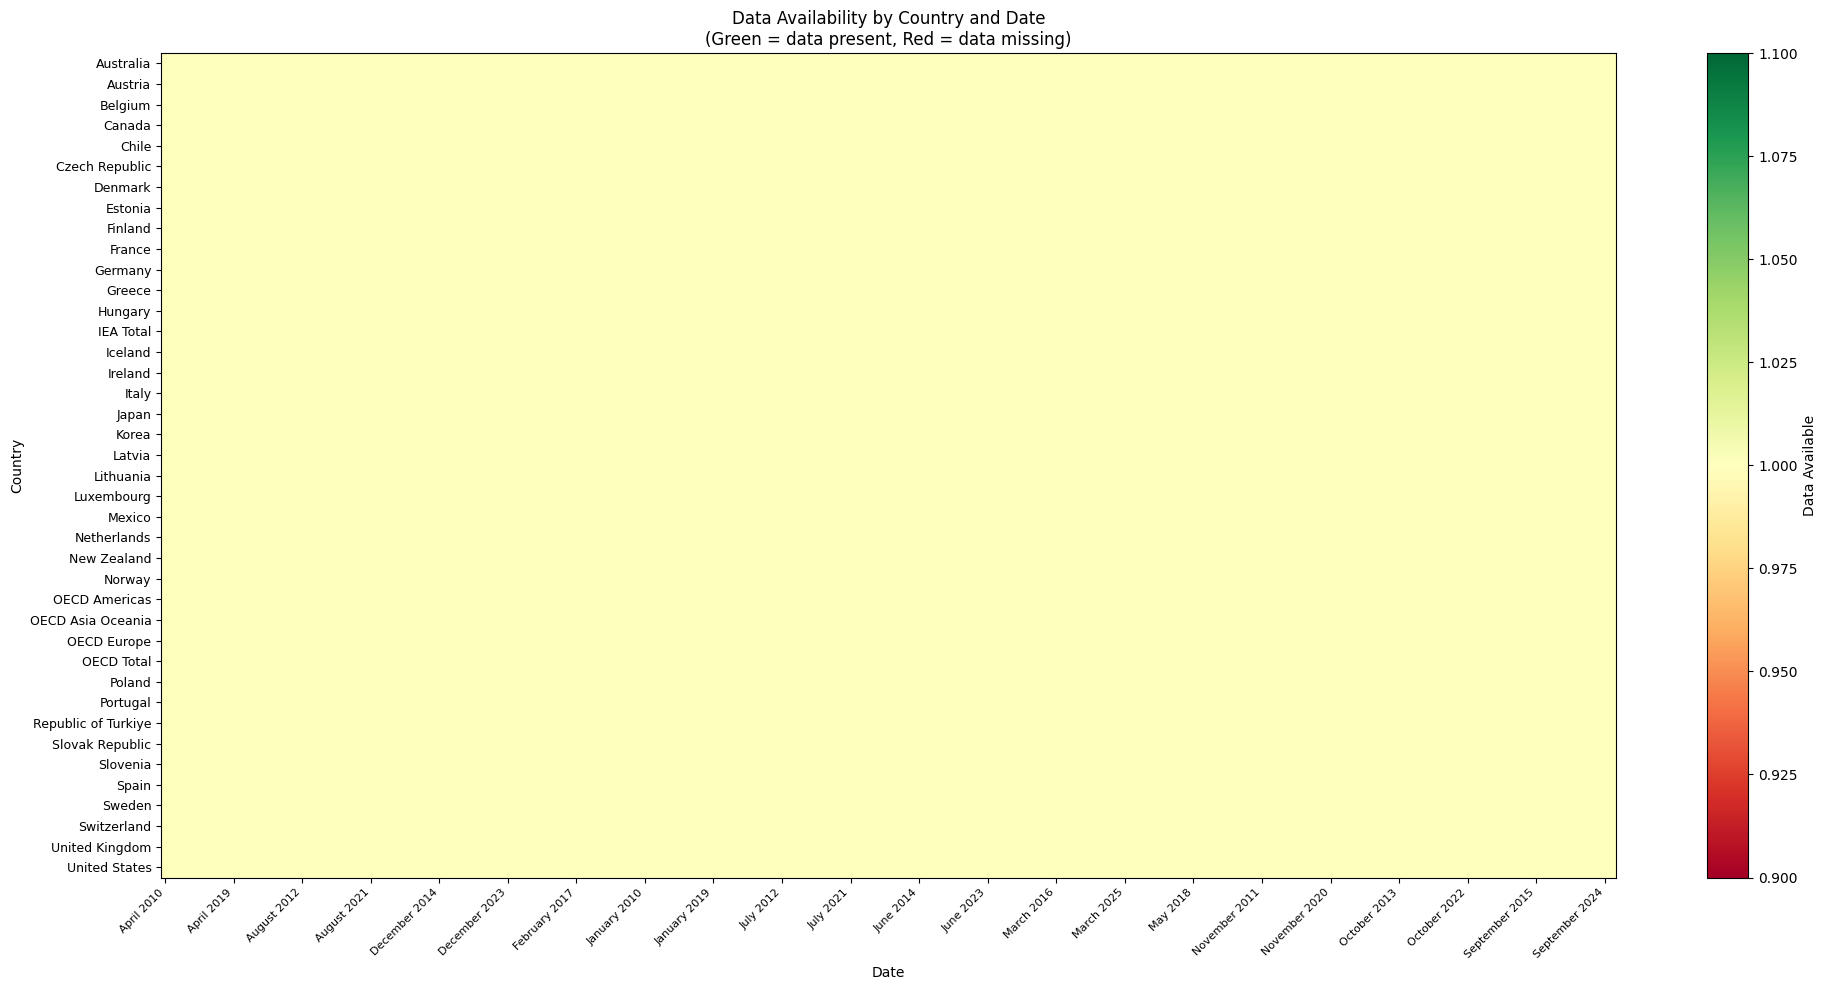


Total countries: 40
Total dates: 191

Dates per country:
  Australia: 191 dates
  Austria: 191 dates
  Belgium: 191 dates
  Canada: 191 dates
  Chile: 191 dates
  Czech Republic: 191 dates
  Denmark: 191 dates
  Estonia: 191 dates
  Finland: 191 dates
  France: 191 dates
  Germany: 191 dates
  Greece: 191 dates
  Hungary: 191 dates
  IEA Total: 191 dates
  Iceland: 191 dates
  Ireland: 191 dates
  Italy: 191 dates
  Japan: 191 dates
  Korea: 191 dates
  Latvia: 191 dates
  Lithuania: 191 dates
  Luxembourg: 191 dates
  Mexico: 191 dates
  Netherlands: 191 dates
  New Zealand: 191 dates
  Norway: 191 dates
  OECD Americas: 191 dates
  OECD Asia Oceania: 191 dates
  OECD Europe: 191 dates
  OECD Total: 191 dates
  Poland: 191 dates
  Portugal: 191 dates
  Republic of Turkiye: 191 dates
  Slovak Republic: 191 dates
  Slovenia: 191 dates
  Spain: 191 dates
  Sweden: 191 dates
  Switzerland: 191 dates
  United Kingdom: 191 dates
  United States: 191 dates


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Get all unique dates
all_dates = sorted(set().union(*dates_by_country.values))

# Create a matrix where rows are countries and columns are dates
date_to_idx = {date: i for i, date in enumerate(all_dates)}
country_list = sorted(dates_by_country.index)

# Create binary matrix (1 if date exists for country, 0 if missing)
matrix = np.zeros((len(country_list), len(all_dates)))
for i, country in enumerate(country_list):
    for date in dates_by_country[country]:
        j = date_to_idx[date]
        matrix[i, j] = 1

# Create heatmap
fig, ax = plt.subplots(figsize=(20, 10))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto')

# Set y-axis to countries
ax.set_yticks(range(len(country_list)))
ax.set_yticklabels(country_list, fontsize=9)

# Set x-axis to dates
ax.set_xticks(range(0, len(all_dates), max(1, len(all_dates)//20)))
ax.set_xticklabels([all_dates[i] for i in range(0, len(all_dates), max(1, len(all_dates)//20))], rotation=45, fontsize=8, ha='right')

ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Country', fontsize=10)
ax.set_title('Data Availability by Country and Date\n(Green = data present, Red = data missing)', fontsize=12)

plt.colorbar(im, ax=ax, label='Data Available')
plt.tight_layout()
plt.show()

# Also print summary
print(f"\nTotal countries: {len(country_list)}")
print(f"Total dates: {len(all_dates)}")
print(f"\nDates per country:")
for country in country_list:
    print(f"  {country}: {len(dates_by_country[country])} dates")


In [27]:
all_dates = set(countries["Time"].unique())

valid_countries = (
    countries.groupby("Country")["Time"]
    .apply(lambda x: set(x) == all_dates)
)
countries = countries[countries["Country"].isin(valid_countries[valid_countries].index)]


In [28]:
countries

7,Country,Time,Balance,Product,Value,Unit
8,Australia,November 2025,Net Electricity Production,Electricity,21355.0142,GWh
9,Australia,November 2025,Net Electricity Production,Hydro,965.5352,GWh
10,Australia,November 2025,Net Electricity Production,Total Combustible Fuels,11343.0954,GWh
11,Australia,November 2025,Net Electricity Production,"Coal, Peat and Manufactured Gases",8266.798,GWh
12,Australia,November 2025,Net Electricity Production,Oil and Petroleum Products,263.3526,GWh
...,...,...,...,...,...,...
157377,IEA Total,January 2010,Total Exports,Electricity,32372.583,GWh
157378,IEA Total,January 2010,Used for pumped storage,Electricity,6869.253,GWh
157379,IEA Total,January 2010,Distribution Losses,Electricity,62000.733,GWh
157380,IEA Total,January 2010,Final Consumption (Calculated),Electricity,877213.615,GWh


In [39]:
preprocessed = pd.read_csv("../Data/preprocessed/ALLCOUNTRIES.csv")
preprocessed.groupby("Country")["Value"].describe()


,count,mean,std,min,25%,50%,75%,max
Country,,,,,,,,
Australia,2917.0,5449.700768,7386.463391,0.0000,222.651000,1206.56890,10411.656600,2.484730e+04
Austria,3534.0,1476.761006,1911.396593,0.0000,67.112375,419.40620,2214.065575,7.599304e+03
Belgium,3534.0,1487.822478,2104.929726,0.0000,119.859575,428.04270,1995.476250,9.184547e+03
Canada,3618.0,10809.795337,16476.824537,0.0000,352.634475,2804.46300,9923.210900,6.659047e+04
Chile,2788.0,1787.292718,2156.921221,0.0000,132.383000,772.01360,2589.025475,7.892851e+03
Czech Republic,3534.0,1402.340911,1888.018940,0.0000,64.441250,359.81350,2328.114500,7.945322e+03
Denmark,3097.0,842.806007,964.258639,0.0000,51.425600,420.18740,1421.799700,4.169415e+03
Estonia,2997.0,238.981442,299.479137,0.0000,4.546300,80.51940,441.673300,1.265361e+03
Finland,3391.0,1428.133842,1983.081331,0.0000,38.122450,656.13000,1866.771300,9.037818e+03
